In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import glob 
import os
root = r'..\co2_calc\emissions_v3'

In [2]:
glo = glob.glob(f'{root}/*.csv', recursive=True)
glo[1]

'..\\co2_calc\\emissions_v3\\Beans_and_legumes_females.csv'

In [3]:
bank = pd.read_excel(r'..\raw_data\2025_World_Bank_classification.xlsx', 'List of economies', header=2)

def grouper(df_path, name=None):
    test = pd.read_csv(df_path)
    try:
        test['income_group'] = test['Country'].map(bank.set_index('Code')['Income group'])
    except:
        test['income_group'] = test['iso3'].map(bank.set_index('Code')['Income group'])

    if name:
        test.to_csv(name, index=False)
    return test

for i in glo:
    os.makedirs(r'..\co2_calc\emissions_v4', exist_ok=True)
    out_name = i.replace('emissions_v3', 'emissions_v4')
    grouper(i, out_name)

In [4]:


# --- 1. Load Data ---
emr_list = glob.glob('..\co2_calc\emissions_v4\*_all.csv')
emr_list = [x for x in emr_list if 'total_all.csv' not in x]

global_list = glob.glob('..\co2_calc\global_emissions\*_all.csv')
global_list = [x for x in global_list if 'total_all.csv' not in x]

# Load EMR files
emr_dfs = []
for f in emr_list:
    df = pd.read_csv(f).dropna(subset=['income_group'])
    df = df[df['year'] != 2020]
    df['food_item'] = f.split('\\')[-1].split('_all')[0]
    # Ensure income_group exists, if not fill with 'Unknown' or handle accordingly
    if 'income_group' not in df.columns:
        df['income_group'] = 'Unknown' 
    emr_dfs.append(df)
combined_df = pd.concat(emr_dfs, ignore_index=True)

# Load Global files
global_dfs = []
for f in global_list:
    global_dfs.append(pd.read_csv(f))
global_df = pd.concat(global_dfs, ignore_index=True)


In [5]:
emr_list[6].split('\\')[-1].split('_')[0]

'Non'

C:\Users\Matin\AppData\Local\Temp\ipykernel_7728\1418891812.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20c', len(all_food_items))


Generating Consumption Plot...


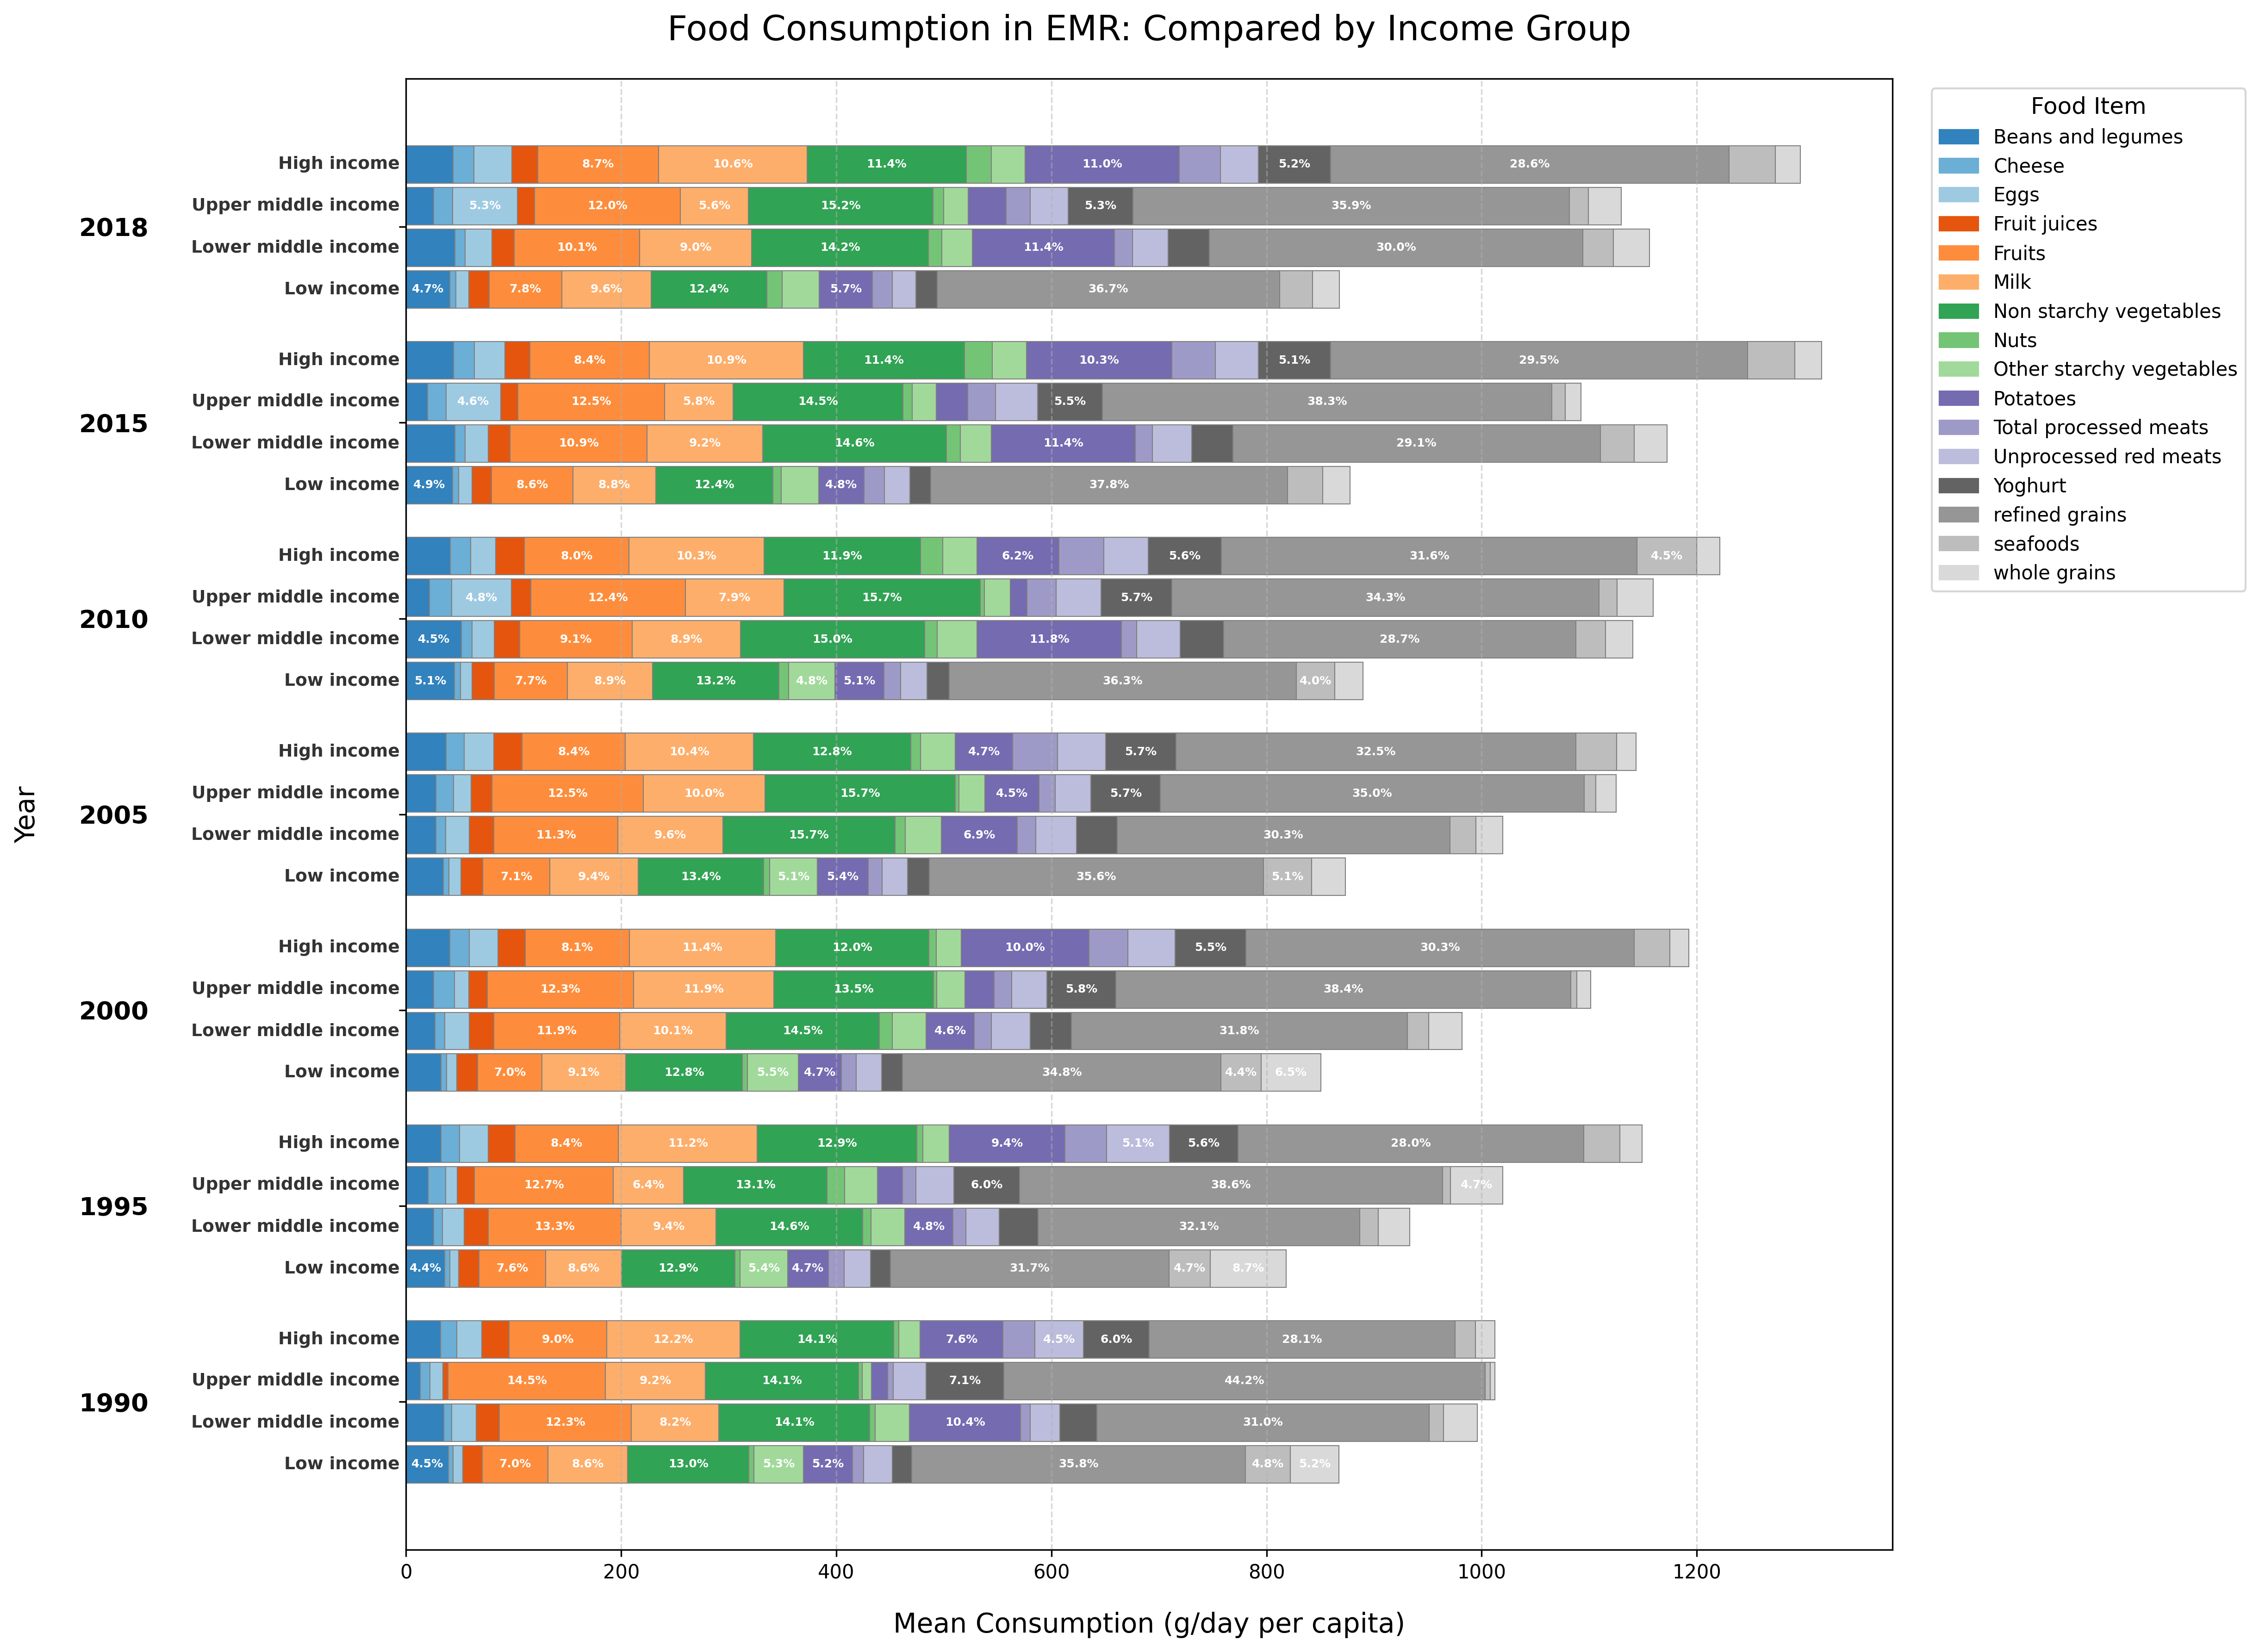

Generating Emission Plot...


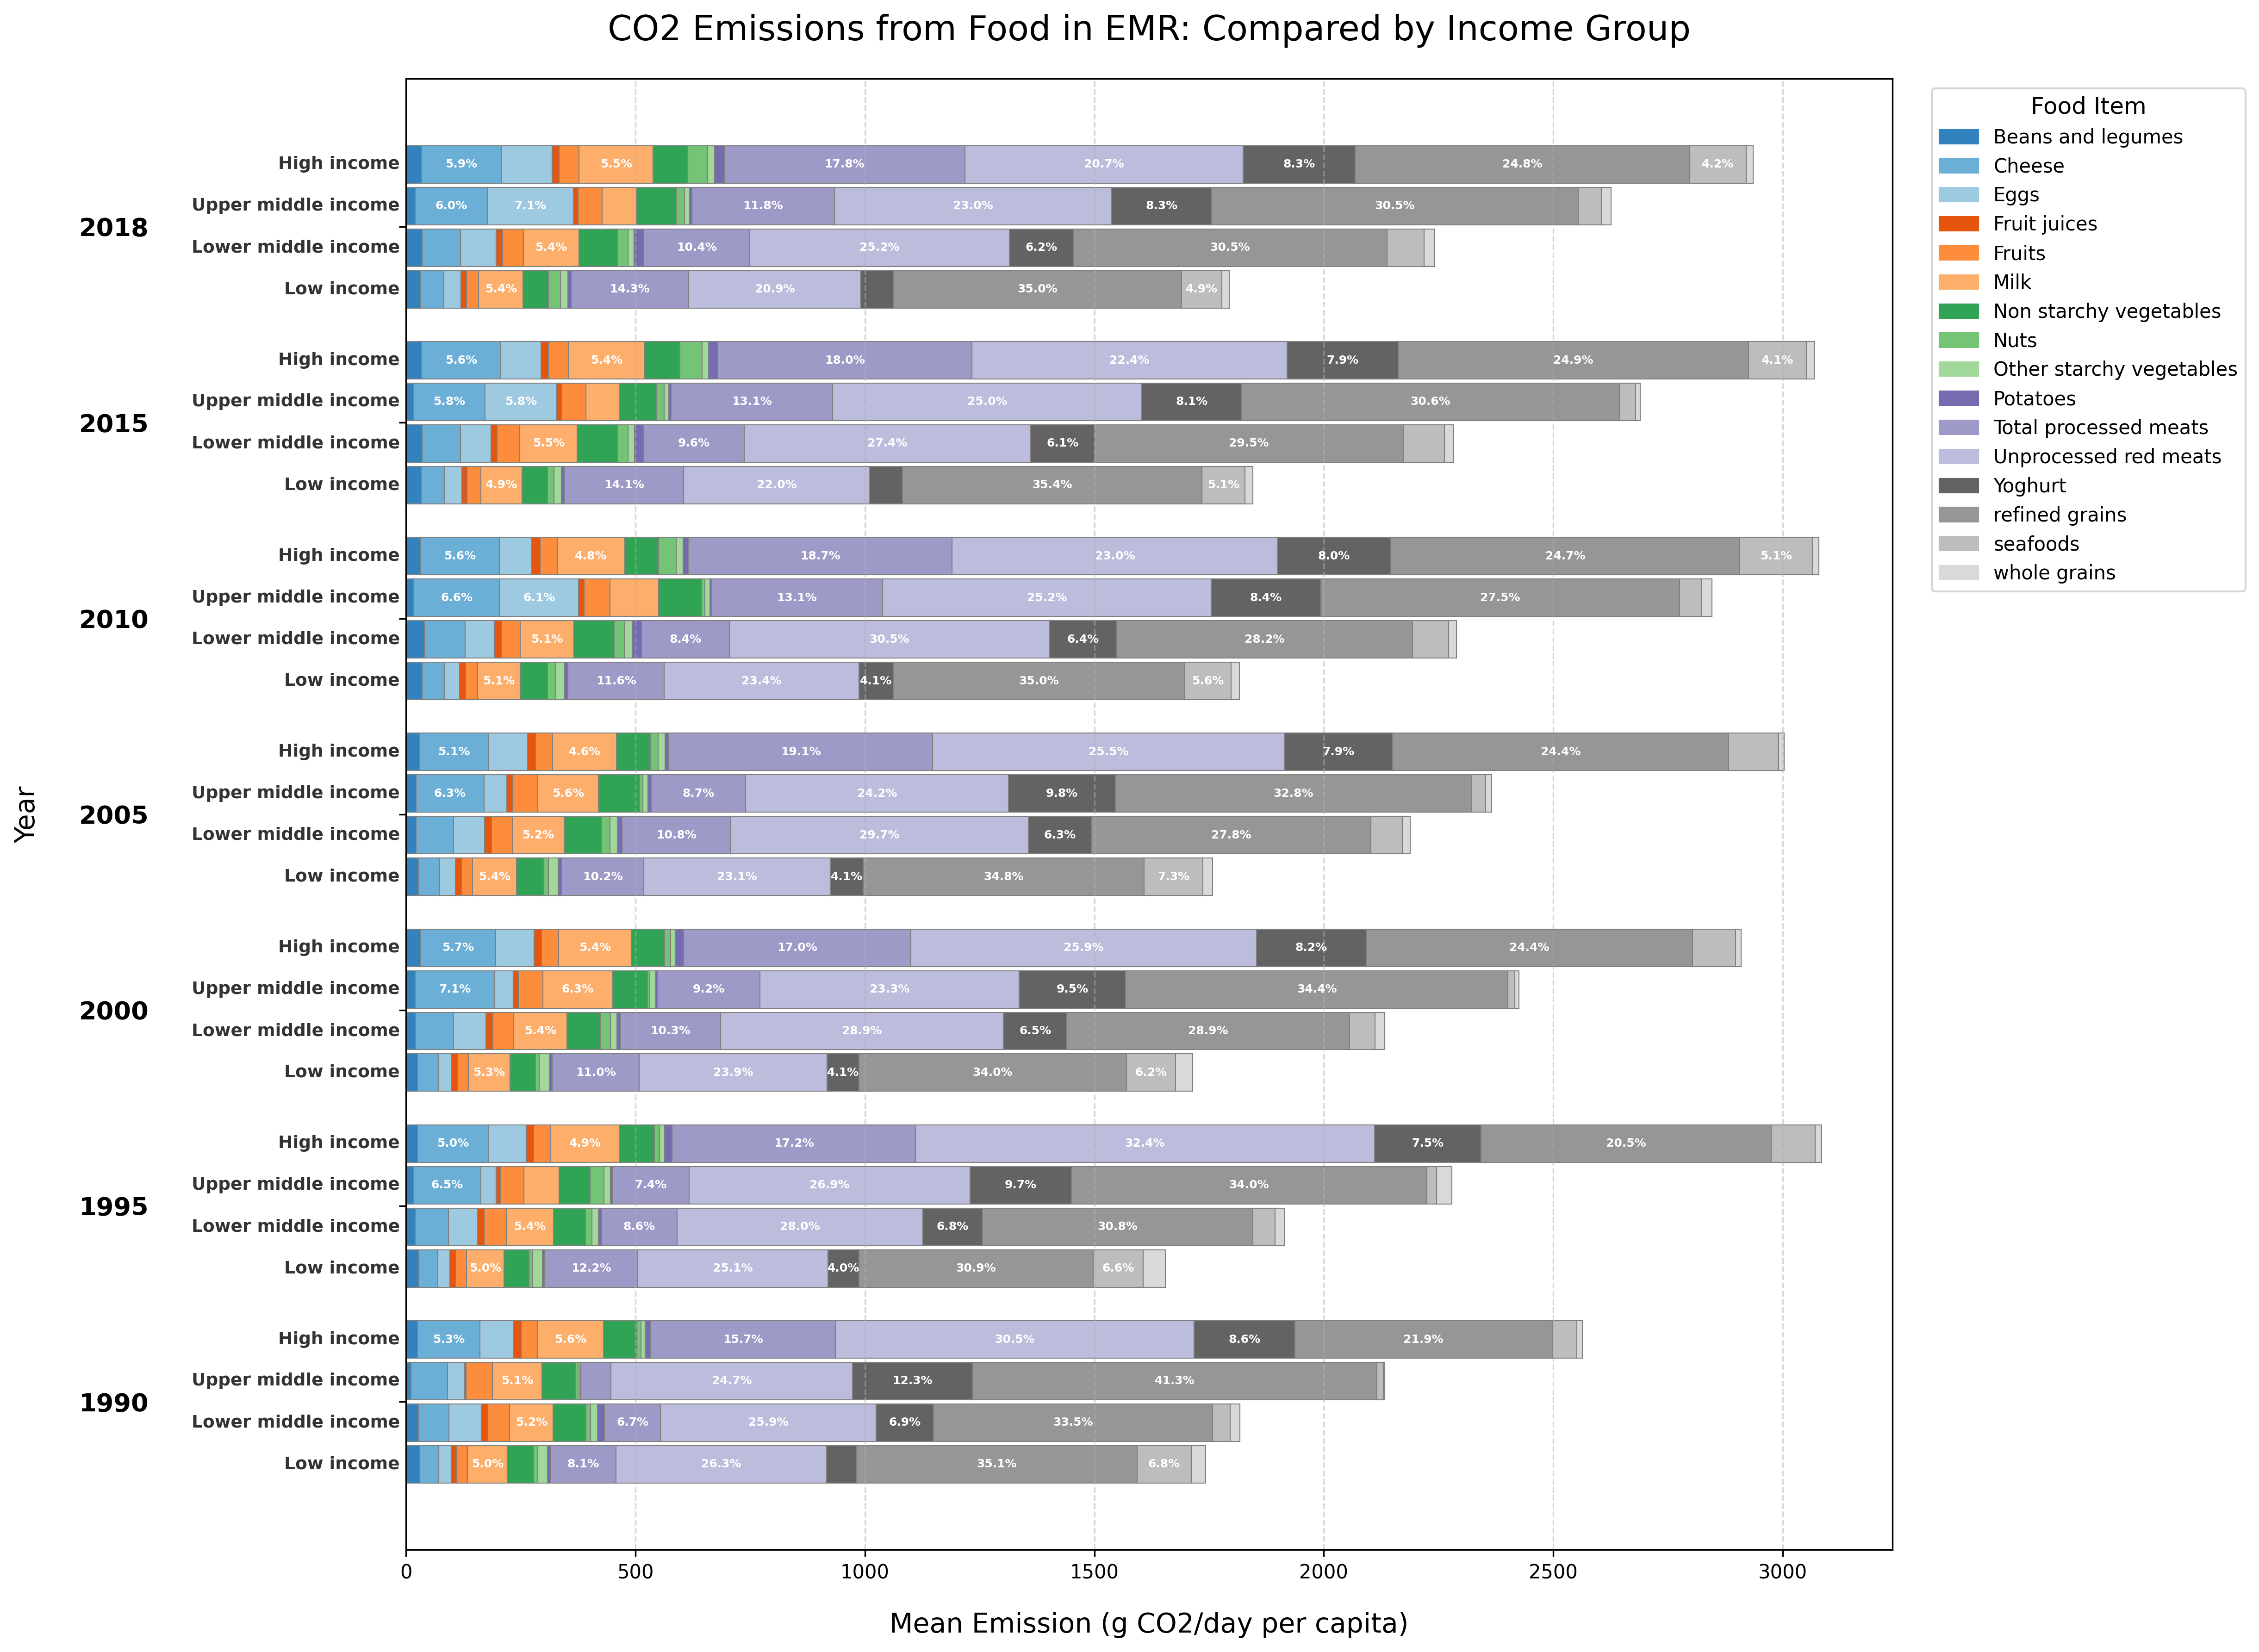

In [6]:
# Ensure year is integer
combined_df['year'] = combined_df['year'].astype(int)
grouped_df = combined_df.groupby(['year', 'income_group', 'food_item'])[['median', 'emissions']].mean().reset_index()

desired_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
unique_groups_from_data = grouped_df['income_group'].unique()

# Sort the unique groups based on the desired order
unique_income_groups = sorted(
    [g for g in unique_groups_from_data if g in desired_order],
    key=lambda x: desired_order.index(x)
)

unique_years = sorted(grouped_df['year'].unique())
all_food_items = sorted(grouped_df['food_item'].unique())

cmap = plt.cm.get_cmap('tab20c', len(all_food_items))
food_color_map = {food: cmap(i) for i, food in enumerate(all_food_items)}

# --- 2. Helper to Create Pivot Tables ---
def create_pivots(value_col):
    pivots = {}
    for ig in unique_income_groups:
        ig_data = grouped_df[grouped_df['income_group'] == ig]
        pivot = ig_data.pivot_table(index='year', columns='food_item', values=value_col, fill_value=0)
        pivot = pivot.reindex(columns=all_food_items, fill_value=0)
        pivot = pivot.reindex(index=unique_years, fill_value=0)
        pivots[ig] = pivot
    return pivots

# Create pivots using your column names
consumption_pivots = create_pivots('median')     # mapped to 'median'
emission_pivots = create_pivots('emissions')     # mapped to 'emissions'

# --- 3. Plotting Function ---
def plot_by_income_group(pivots_dict, metric_name, ylabel, title, filename):
    # Increased figure width slightly to accommodate left padding
    fig, ax = plt.subplots(figsize=(22, 12), dpi=300)
    
    n_groups = len(unique_income_groups)
    total_bar_height_per_year = 0.85 
    bar_height = total_bar_height_per_year / n_groups
    
    y_centers = np.arange(len(unique_years))
    
    # Calculate offsets based on the sorted groups
    offsets = np.linspace(-total_bar_height_per_year/2 + bar_height/2, 
                          total_bar_height_per_year/2 - bar_height/2, 
                          n_groups)
    
    for i, year_val in enumerate(unique_years):
        # Iterate through the SORTED unique_income_groups
        for j, ig in enumerate(unique_income_groups):
            
            pivot = pivots_dict[ig]
            if year_val not in pivot.index: continue
            row_data = pivot.loc[year_val]
            total_val = row_data.sum()
            
            y_pos = y_centers[i] + offsets[j]
            
            left_curr = 0
            for food in all_food_items:
                val = row_data[food]
                if val > 0:
                    ax.barh(
                        y_pos, val, left=left_curr, height=bar_height * 0.9, 
                        color=food_color_map[food], edgecolor='grey', linewidth=0.5
                    )
                    
                    # Annotation if > 4%
                    prop = val / total_val if total_val > 0 else 0
                    if prop > 0.04:
                        ax.text(left_curr + val/2, y_pos, f'{prop:.1%}', 
                                ha='center', va='center', color='white', 
                                fontsize=6, weight='bold')
                    
                    left_curr += val
            
            # Label the Income Group at x = -0.5 (slightly left of the bar start)
            ax.text(-0.5, y_pos, f'{ig} ', ha='right', va='center', 
                    fontsize=9, weight='bold', color='#333333')

    # Formatting
    ax.set_yticks(y_centers)
    ax.set_yticklabels(unique_years, fontsize=13, weight='bold')
    
    # --- KEY FIX 1: Padding ---
    # Push the Year labels 130 points to the left to make room for Income Group labels
    ax.tick_params(axis='y', which='major', pad=130) 
    
    ax.set_xlabel(ylabel, fontsize=14, labelpad=15)
    ax.set_ylabel('Year', fontsize=14, labelpad=20)
    ax.set_title(title, fontsize=18, pad=20)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # --- KEY FIX 2: Legend Layout ---
    handles = [plt.Rectangle((0,0),1,1, color=food_color_map[food]) for food in all_food_items]
    labels = [food.replace('_', ' ') for food in all_food_items]
    
    # Place legend outside top-right
    ax.legend(handles, labels, title='Food Item', title_fontsize=12,
              bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    
    # Adjust layout rect: [left, bottom, right, top]
    # left=0.15 gives room for the padded year labels
    # right=0.90 gives room for the legend
    plt.tight_layout(rect=[0.15, 0, 0.90, 1])
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --- 4. Generate Plots ---
print("Generating Consumption Plot...")
plot_by_income_group(consumption_pivots, 'Consumption', 
                     'Mean Consumption (g/day per capita)', 
                     'Food Consumption in EMR: Compared by Income Group', 
                     'figures/mean_consumption_income_group.png')

print("Generating Emission Plot...")
plot_by_income_group(emission_pivots, 'Emission', 
                     'Mean Emission (g CO2/day per capita)', 
                     'CO2 Emissions from Food in EMR: Compared by Income Group', 
                     'figures/mean_emission_income_group.png')

In [7]:
# mf = pd.read_csv(r'D:\Prog\ICRI\climate_change\raw_data\Country-level estimates\v10_cnty.csv')
# mf[(mf['iso3'] == 'IRQ') & (mf['age'] == 999) & (mf['edu'] == 999) & (mf['female'] == 999) & (mf['urban'] == 999)]